In [2]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import re


class Account:
    _account_counter = 1000
    
    @staticmethod
    def _validate_name(name):
        pattern = r'^[А-ЯЁA-Z][а-яёa-z]+\s[А-ЯЁA-Z][а-яёa-z]+$'
        if not re.match(pattern, name):
            raise ValueError("Имя должно быть в формате 'Имя Фамилия' с заглавных букв")
    
    def __init__(self, account_holder, balance=0):
        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным")
        
        self._validate_name(account_holder)
        
        self.holder = account_holder # владелец счета
        self.account_number = f"ACC-{Account._account_counter}" # номер счета
        Account._account_counter += 1
        self._balance = balance # баланс счета
        self.operations_history = [] # история операций
        
        if balance > 0:
            # если баланс больше 0, то добавляем операцию пополнения
            self.operations_history.append({
                'type': 'deposit',
                'amount': balance,
                'datetime': datetime.now(),
                'balance_after': self._balance,
                'status': 'success'
            })
    
    def deposit(self, amount):
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной")
        
        self._balance += amount
        self.operations_history.append({
            'type': 'deposit',
            'amount': amount,
            'datetime': datetime.now(),
            'balance_after': self._balance,
            'status': 'success'
        })
    
    def withdraw(self, amount):
        if amount <= 0:
            raise ValueError("Сумма снятия должна быть положительной")
        
        if self._balance >= amount:
            self._balance -= amount
            self.operations_history.append({
                'type': 'withdraw',
                'amount': amount,
                'datetime': datetime.now(),
                'balance_after': self._balance,
                'status': 'success'
            })
        else:
            self.operations_history.append({
                'type': 'withdraw',
                'amount': amount,
                'datetime': datetime.now(),
                'balance_after': self._balance,
                'status': 'fail'
            })
    
    def get_balance(self):
        return self._balance
    
    def get_history(self):
        return self.operations_history
    
    def get_largest_operations(self, n=5):
        successful_operations = [op for op in self.operations_history if op['status'] == 'success']
        sorted_operations = sorted(successful_operations, key=lambda x: x['amount'], reverse=True)
        return sorted_operations[:n]
    
    def plot_history(self):
        if not self.operations_history:
            print("История операций пуста")
            return
        
        df = pd.DataFrame(self.operations_history)
        
        plt.figure(figsize=(10, 6))
        plt.plot(df['datetime'], df['balance_after'], marker='o', linestyle='-', linewidth=2)
        plt.xlabel('Время операции')
        plt.ylabel('Баланс после операции')
        plt.title(f'История изменения баланса счёта {self.account_number}')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()





Проверка выполнения

Номер счёта: ACC-1000
Владелец: Павел Брагин
Начальный баланс: 1000

После пополнения на 500: 1500
После снятия 300: 1200
После попытки снять 2000: 1200
После пополнения на 1500: 2700

История операций:
1. {'type': 'deposit', 'amount': 1000, 'datetime': datetime.datetime(2025, 11, 8, 13, 16, 31, 591171), 'balance_after': 1000, 'status': 'success'}
2. {'type': 'deposit', 'amount': 500, 'datetime': datetime.datetime(2025, 11, 8, 13, 16, 31, 591333), 'balance_after': 1500, 'status': 'success'}
3. {'type': 'withdraw', 'amount': 300, 'datetime': datetime.datetime(2025, 11, 8, 13, 16, 31, 591345), 'balance_after': 1200, 'status': 'success'}
4. {'type': 'withdraw', 'amount': 2000, 'datetime': datetime.datetime(2025, 11, 8, 13, 16, 31, 591358), 'balance_after': 1200, 'status': 'fail'}
5. {'type': 'deposit', 'amount': 1500, 'datetime': datetime.datetime(2025, 11, 8, 13, 16, 31, 591370), 'balance_after': 2700, 'status': 'success'}


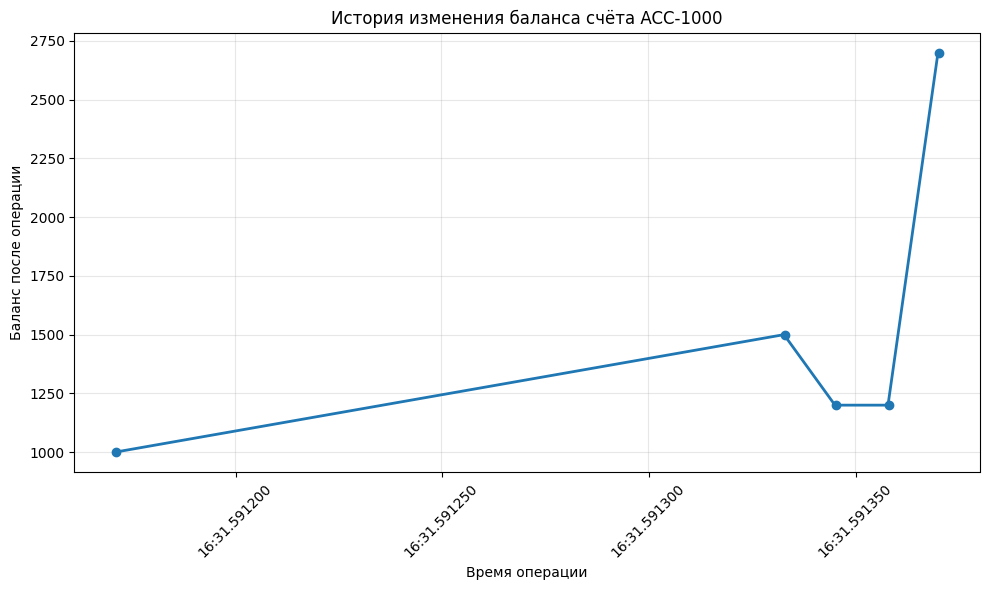

In [ ]:
if __name__ == "__main__":
    
    account = Account("Павел Брагин", 1000)
    
    print(f"Номер счёта: {account.account_number}")
    print(f"Владелец: {account.holder}")
    print(f"Начальный баланс: {account.get_balance()}")
    print()
    
    account.deposit(500)
    print(f"После пополнения на 500: {account.get_balance()}")
    
    account.withdraw(300)
    print(f"После снятия 300: {account.get_balance()}")
    
    account.withdraw(2000)
    print(f"После попытки снять 2000: {account.get_balance()}")
    
    account.deposit(1500)
    print(f"После пополнения на 1500: {account.get_balance()}")
    print()
    
    print("История операций:")
    for i, operation in enumerate(account.get_history(), 1):
        print(f"{i}. {operation}")
    
    account.plot_history()